In [1]:
1+1

2

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open("../data/names.txt", 'r').read().splitlines()
print(len(words))
print(words[:8])

32033
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
VOCAB_SIZE = len(itos)
print(itos)
print(VOCAB_SIZE)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
import random
random.seed(42)
random.shuffle(words)

In [108]:
BLOCK_SIZE = 3
def build_dataset(words):
    X, y = [], []
    for w in words:
        context = [0] * BLOCK_SIZE
        for c in w + '.':
            ix = stoi[c]
            X.append(context)
            y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, ytr = build_dataset(words[:n1])
Xde, yde = build_dataset(words[n1:n2])
Xte, yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
# printing a sample out of the dataset

for x, y in zip(Xtr[:20], ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()] )

... ---> y
..y ---> u
.yu ---> h
yuh ---> e
uhe ---> n
hen ---> g
eng ---> .
... ---> d
..d ---> i
.di ---> o
dio ---> n
ion ---> d
ond ---> r
ndr ---> e
dre ---> .
... ---> x
..x ---> a
.xa ---> v
xav ---> i
avi ---> e


In [109]:
from typing import Any


class Linear:
    def __init__(self, fan_in, fan_out, bias) -> None:
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x) -> Any:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        
        return self.out
        
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_var = torch.ones(dim)
        self.running_mean = torch.zeros(dim)

    def __call__(self, x) -> Any:
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x) -> Any:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

        

In [110]:
torch.manual_seed(42);

In [111]:
n_embd = 10
n_hidden = 200

C = torch.randn((VOCAB_SIZE, n_embd))
layers = [
    Linear(n_embd * BLOCK_SIZE, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, VOCAB_SIZE, bias=False),
]

with torch.no_grad():
    layers[-1].weight *= 0.1 # to make last layer less confident

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

12070


In [112]:
EPOCHS = 200000
BATCH_SIZE = 32
lossi = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ))
    Xb, yb = Xtr[ix], ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    LR = 0.1 if epoch < 150000 else 0.01
    for p in parameters:
        p.data -= LR * p.grad

    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    
    lossi.append(loss.log10().item())

      0/ 200000: 3.2966
  10000/ 200000: 2.2346
  20000/ 200000: 2.3566
  30000/ 200000: 2.1195
  40000/ 200000: 2.3588
  50000/ 200000: 2.3033
  60000/ 200000: 1.9701
  70000/ 200000: 1.9512
  80000/ 200000: 2.7122
  90000/ 200000: 2.0172
 100000/ 200000: 2.2325
 110000/ 200000: 1.7103
 120000/ 200000: 2.2338
 130000/ 200000: 2.3267
 140000/ 200000: 2.0584
 150000/ 200000: 1.8964
 160000/ 200000: 1.8406
 170000/ 200000: 2.2953
 180000/ 200000: 2.0206
 190000/ 200000: 2.1024


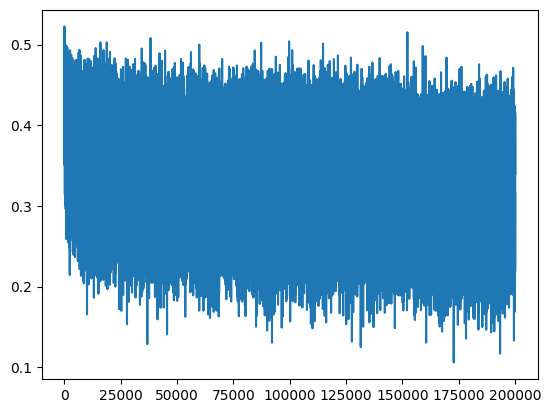

In [23]:
plt.plot(lossi)

The loss is fluctuating a lot, maybe because the batch size is too little, so model is either super lucky or super unlucky with the batches and hence loss is volatile

In [21]:
for layer in layers:
    layer.training = False

In [113]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test': (Xte, yte)
    }[split]

    emb = C[x]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0587728023529053
val 2.10703444480896


In [24]:
#sample from the current model
SAMPLES = 20
for _ in range(SAMPLES):
    out = []
    context = [0] * BLOCK_SIZE

    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        
        logits = x
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

rolan.
osali.
anz.
xyah.
apeuniel.
ida.
lyoerleigh.
sua.
jatta.
koba.
kinstiny.
ana.
abrus.
milora.
saclyn.
tanii.
lla.
anthen.
jashtyn.
rose.


Lets fix the lossi plot

In [26]:
len(lossi)

200000

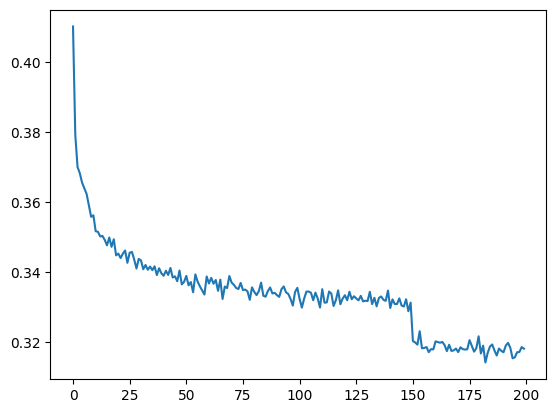

In [38]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

This looks much better, we basically just computed the mean of each 1000 epochs and then ploted it...As you can see around 150000th epoch, the loss decreased even more due to the LR decay

Now lets prettify the forawrd pass, its still long

In [114]:
from typing import Any


class Linear:
    def __init__(self, fan_in, fan_out, bias) -> None:
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x) -> Any:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        
        return self.out
        
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_var = torch.ones(dim)
        self.running_mean = torch.zeros(dim)

    def __call__(self, x) -> Any:
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x) -> Any:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

        
class Embedding:
    def __init__(self, num_embeddings, embedding_dim) -> None:
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX) -> Any:
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x) -> Any:
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []
    
class Sequential: # to not store all the layers in a raw list and then do for layer in layers: x = layer(p)
    def __init__(self, layers) -> None:
        self.layers = layers
        
    def __call__(self, x) -> Any:
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [100]:
n_embd = 10
n_hidden = 200

model = Sequential([
    Embedding(VOCAB_SIZE, n_embd),
    Flatten(),
    Linear(n_embd * BLOCK_SIZE, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, VOCAB_SIZE, bias=False),
])

# with torch.no_grad():
#     layers[-1].weight *= 0.1 # to make last layer less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

12070


In [101]:
EPOCHS = 200000
BATCH_SIZE = 32
lossi = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ))
    Xb, yb = Xtr[ix], ytr[ix]
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    LR = 0.1 if epoch < 150000 else 0.01
    for p in parameters:
        p.data -= LR * p.grad

    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    
    lossi.append(loss.log10().item())

      0/ 200000: 3.4282
  10000/ 200000: 2.3909
  20000/ 200000: 2.0185
  30000/ 200000: 1.9976
  40000/ 200000: 2.4637
  50000/ 200000: 2.1085
  60000/ 200000: 2.5199
  70000/ 200000: 2.2696
  80000/ 200000: 2.1178
  90000/ 200000: 2.3178
 100000/ 200000: 2.1049
 110000/ 200000: 2.1854
 120000/ 200000: 2.0958
 130000/ 200000: 2.2373
 140000/ 200000: 1.9952
 150000/ 200000: 2.3532
 160000/ 200000: 1.9986
 170000/ 200000: 1.8186
 180000/ 200000: 2.1396
 190000/ 200000: 1.9160


In [102]:
model.layers[3].training = False

In [87]:
for layers in model.layers:
    layer.training = False

In [103]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test': (Xte, yte)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())
split_loss('train')

train 2.0611112117767334


In [104]:
#sample from the current model
SAMPLES = 20
for _ in range(SAMPLES):
    out = []
    context = [0] * BLOCK_SIZE

    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

jaxuelie.
avien.
chianah.
roy.
zatoliko.
genna.
toe.
niya.
auv.
solfa.
kamilo.
vair.
ela.
emris.
fatra.
mary.
jouris.
auston.
baybran.
abibi.


Lets increase the context size and see now

In [115]:
BLOCK_SIZE = 8
def build_dataset(words):
    X, y = [], []
    for w in words:
        context = [0] * BLOCK_SIZE
        for c in w + '.':
            ix = stoi[c]
            X.append(context)
            y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, ytr = build_dataset(words[:n1])
Xde, yde = build_dataset(words[n1:n2])
Xte, yte = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [116]:
n_embd = 10
n_hidden = 200

model = Sequential([
    Embedding(VOCAB_SIZE, n_embd),
    Flatten(),
    Linear(n_embd * BLOCK_SIZE, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, VOCAB_SIZE, bias=False),
])

# with torch.no_grad():
#     layers[-1].weight *= 0.1 # to make last layer less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

22070


In [117]:
EPOCHS = 200000
BATCH_SIZE = 32
lossi = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ))
    Xb, yb = Xtr[ix], ytr[ix]
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    LR = 0.1 if epoch < 150000 else 0.01
    for p in parameters:
        p.data -= LR * p.grad

    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    
    lossi.append(loss.log10().item())

      0/ 200000: 3.6449
  10000/ 200000: 2.1907
  20000/ 200000: 2.3007
  30000/ 200000: 2.0967
  40000/ 200000: 2.0369
  50000/ 200000: 2.1207
  60000/ 200000: 1.9519
  70000/ 200000: 2.3577
  80000/ 200000: 1.5849
  90000/ 200000: 1.7718
 100000/ 200000: 1.6603
 110000/ 200000: 2.7233
 120000/ 200000: 2.3012
 130000/ 200000: 2.2535
 140000/ 200000: 1.9951
 150000/ 200000: 2.1545
 160000/ 200000: 1.7227
 170000/ 200000: 1.7798
 180000/ 200000: 1.9391
 190000/ 200000: 1.8627


In [118]:
model.layers[3].training = False

In [ ]:
for layers in model.layers:
    layer.training = False

In [119]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test': (Xte, yte)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())
split_loss('train')
split_loss('val')

train 1.9235178232192993
val 2.0306460857391357


In [120]:
#sample from the current model
SAMPLES = 20
for _ in range(SAMPLES):
    out = []
    context = [0] * BLOCK_SIZE

    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

sdally.
elli.
thanira.
romin.
adnyea.
kiandrema.
ferelyn.
elmen.
jerelyn.
caisleenia.
keval.
samriya.
alcour.
taolis.
ranner.
shton.
daarlito.
marpot.
braxlynn.
vashaun.


### Performance log
- Original with context 3 -> validation loss = 2.10
- with context 8 -> validation loss = 2.03


RIght now, we are just using a single hidden layer and all the data, the 8 previous chars are getting smashed into a single layer, lets implement the wavenet paper, where we are dividing the contexts and sending them to different neurons, like 1st 2 chars go to different neurons and last 2 will go to different neurons and so on


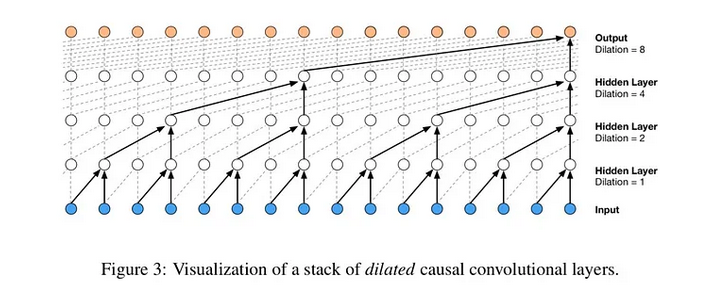

Now, to do that, we need to check some things....

In [124]:
# whats the input shape we give to the C emb vector??

ix = torch.randint(0, Xtr.shape[0], (4,)) # just taking a batchsize of 4 rightnow
Xb, yb = Xtr[ix], ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0, 11, 12, 25, 14, 14],
        [ 0,  9, 12,  9,  1, 14, 14,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  3]])

In [128]:
model.layers[0].out.shape # here there are 4 examples, each example has 8 characters, and each character has 10 embeddings

torch.Size([4, 8, 10])

In [129]:
model.layers[1].out.shape # that is getting flattened by the flattening layer

torch.Size([4, 80])

In [130]:
model.layers[2].out.shape # that is getting matmul by linear layer with 80 inputs and 200 neurons...ie. the 80 inputs all are going to the neuron at once, and then matmul and then 
                            # outcomes a matrix of 200 neurons per example

torch.Size([4, 200])

Now what we need to do is...instead of sending the full 4,80 flatten layer output, we need to group those chars 

(1 2 3 4 5 6 7 8) this is going in as 1 group

we have to group them into 4 groups of 2

(1 2) (3 4) (5 6) (7 8)


In [132]:
# instead of 
(torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape

# we will do

(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape

torch.Size([4, 4, 200])

Lets change the flatten to do this

In [138]:
from typing import Any


class Linear:
    def __init__(self, fan_in, fan_out, bias) -> None:
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x) -> Any:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        
        return self.out
        
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_var = torch.ones(dim)
        self.running_mean = torch.zeros(dim)

    def __call__(self, x) -> Any:
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x) -> Any:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

        
class Embedding:
    def __init__(self, num_embeddings, embedding_dim) -> None:
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX) -> Any:
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    
    def __init__(self, n) -> None: # n is you want groups of how many chars??
        self.n = n

    def __call__(self, x) -> Any:
        B, T, C, = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential: # to not store all the layers in a raw list and then do for layer in layers: x = layer(p)
    def __init__(self, layers) -> None:
        self.layers = layers
        
    def __call__(self, x) -> Any:
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [139]:
n_embd = 10
n_hidden = 200

model = Sequential([
    Embedding(VOCAB_SIZE, n_embd),
    FlattenConsecutive(8), # testing it out by making groups of 8 chars, just what we were doing before
    Linear(n_embd * BLOCK_SIZE, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, VOCAB_SIZE, bias=False),
])

# with torch.no_grad():
#     layers[-1].weight *= 0.1 # to make last layer less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

22070


In [141]:
# whats the input shape we give to the C emb vector??

ix = torch.randint(0, Xtr.shape[0], (4,)) # just taking a batchsize of 4 rightnow
Xb, yb = Xtr[ix], ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  5, 22,  5, 12],
        [ 0,  0,  0,  0,  0,  4,  1, 14],
        [ 0,  0,  0,  0,  0,  0,  0,  4]])

In [142]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 80)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


Does the same thing, now lets make it 2

In [149]:
n_embd = 10
n_hidden = 68 # reducing the n_hidden to get almost the same parameters to check the effiiency

model = Sequential([
    Embedding(VOCAB_SIZE, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, VOCAB_SIZE, bias=False),
])

# with torch.no_grad():
#     layers[-1].weight *= 0.1 # to make last layer less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

22370


In [147]:
# whats the input shape we give to the C emb vector??

ix = torch.randint(0, Xtr.shape[0], (4,)) # just taking a batchsize of 4 rightnow
Xb, yb = Xtr[ix], ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 22,  9, 14, 19],
        [ 0,  0,  0,  0,  0,  0,  0, 15],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 17, 21]])

In [148]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [150]:
EPOCHS = 200000
BATCH_SIZE = 32
lossi = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ))
    Xb, yb = Xtr[ix], ytr[ix]
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    LR = 0.1 if epoch < 150000 else 0.01
    for p in parameters:
        p.data -= LR * p.grad

    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    
    lossi.append(loss.log10().item())

      0/ 200000: 3.6867
  10000/ 200000: 1.9728
  20000/ 200000: 2.0408
  30000/ 200000: 1.8514
  40000/ 200000: 1.9285
  50000/ 200000: 2.1558
  60000/ 200000: 2.1613
  70000/ 200000: 2.0877
  80000/ 200000: 2.1181
  90000/ 200000: 1.7336
 100000/ 200000: 1.8580
 110000/ 200000: 2.2568
 120000/ 200000: 1.8337
 130000/ 200000: 1.8401
 140000/ 200000: 1.7623
 150000/ 200000: 2.1510
 160000/ 200000: 2.0403
 170000/ 200000: 2.2089
 180000/ 200000: 1.9637
 190000/ 200000: 1.6612


In [151]:
model.layers[3].training = False
model.layers[6].training = False
model.layers[9].training = False

In [ ]:
for layers in model.layers:
    layer.training = False

In [152]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test': (Xte, yte)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())
split_loss('train')
split_loss('val')

train 1.9341851472854614
val 2.021589517593384


### Performance log
- Original with context 3 -> validation loss = 2.10
- with context 8 -> validation loss = 2.03
- with wavenet -> 2.02


There's a bug, in the batchnorm layer, as usual...

Right now, we are calculating the mean in the 0th dim...that is we are calculating the mean only on the examples..but now we also want to calculate the mean in examples and the group, ie the 2nd dim

In [158]:
# running mean shape to prove previous point

model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [171]:
from typing import Any


class Linear:
    def __init__(self, fan_in, fan_out, bias) -> None:
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x) -> Any:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        
        return self.out
        
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_var = torch.ones(dim)
        self.running_mean = torch.zeros(dim)

    def __call__(self, x) -> Any:
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1) # changed this line

            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x) -> Any:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

        
class Embedding:
    def __init__(self, num_embeddings, embedding_dim) -> None:
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX) -> Any:
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    
    def __init__(self, n) -> None: # n is you want groups of how many chars??
        self.n = n

    def __call__(self, x) -> Any:
        B, T, C, = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential: # to not store all the layers in a raw list and then do for layer in layers: x = layer(p)
    def __init__(self, layers) -> None:
        self.layers = layers
        
    def __call__(self, x) -> Any:
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [172]:
n_embd = 10
n_hidden = 68 # reducing the n_hidden to get almost the same parameters to check the effiiency

model = Sequential([
    Embedding(VOCAB_SIZE, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, VOCAB_SIZE, bias=False),
])

# with torch.no_grad():
#     layers[-1].weight *= 0.1 # to make last layer less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

22370


In [168]:
# whats the input shape we give to the C emb vector??

ix = torch.randint(0, Xtr.shape[0], (4,)) # just taking a batchsize of 4 rightnow
Xb, yb = Xtr[ix], ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 5, 13,  5, 20, 18,  9,  3,  5],
        [ 0,  0,  8, 21, 20,  3,  8,  9],
        [ 0,  2, 21, 18, 11, 12,  5, 25]])

In [169]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [170]:
# running mean shape to prove previous point

model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

Now the bug is solved

Training it again

In [173]:
EPOCHS = 200000
BATCH_SIZE = 32
lossi = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ))
    Xb, yb = Xtr[ix], ytr[ix]
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    LR = 0.1 if epoch < 150000 else 0.01
    for p in parameters:
        p.data -= LR * p.grad

    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    
    lossi.append(loss.log10().item())

      0/ 200000: 3.4705
  10000/ 200000: 2.0364
  20000/ 200000: 2.2970
  30000/ 200000: 2.0477
  40000/ 200000: 2.1369
  50000/ 200000: 2.4310
  60000/ 200000: 2.2887
  70000/ 200000: 2.2850
  80000/ 200000: 1.9283
  90000/ 200000: 2.1388
 100000/ 200000: 2.1304
 110000/ 200000: 2.1659
 120000/ 200000: 2.2513
 130000/ 200000: 1.8244
 140000/ 200000: 2.2710
 150000/ 200000: 2.0119
 160000/ 200000: 1.8724
 170000/ 200000: 1.7999
 180000/ 200000: 2.1405
 190000/ 200000: 1.8271


In [174]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test': (Xte, yte)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())
split_loss('train')
split_loss('val')

train 1.9110325574874878
val 2.016981840133667


### Performance log
- Original with context 3 -> validation loss = 2.10
- with context 8 -> validation loss = 2.03
- with wavenet -> 2.02
- with batchnorm bug fixed -> 2.01


Now lets scale up the architecture and try once

In [175]:
n_embd = 24
n_hidden = 128 # reducing the n_hidden to get almost the same parameters to check the effiiency

model = Sequential([
    Embedding(VOCAB_SIZE, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, VOCAB_SIZE, bias=False),
])

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

76552


In [176]:
EPOCHS = 200000
BATCH_SIZE = 32
lossi = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ))
    Xb, yb = Xtr[ix], ytr[ix]
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    LR = 0.1 if epoch < 150000 else 0.01
    for p in parameters:
        p.data -= LR * p.grad

    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    
    lossi.append(loss.log10().item())

      0/ 200000: 3.4838
  10000/ 200000: 2.0915
  20000/ 200000: 1.4213
  30000/ 200000: 1.9326
  40000/ 200000: 2.1459
  50000/ 200000: 1.9366
  60000/ 200000: 2.1812
  70000/ 200000: 2.1826
  80000/ 200000: 2.1078
  90000/ 200000: 2.3885
 100000/ 200000: 2.3698
 110000/ 200000: 1.8832
 120000/ 200000: 1.9172
 130000/ 200000: 2.0203
 140000/ 200000: 1.7627
 150000/ 200000: 1.9069
 160000/ 200000: 1.9468
 170000/ 200000: 1.6328
 180000/ 200000: 1.6703
 190000/ 200000: 1.7743


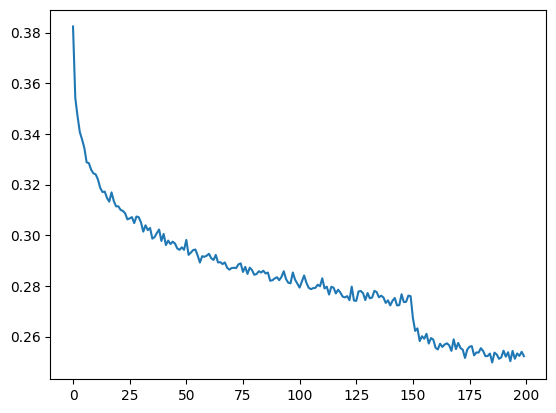

In [177]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [178]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test': (Xte, yte)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())
split_loss('train')
split_loss('val')

train 1.7670655250549316
val 1.990767240524292
